# Pediatric chest X-rays: domain adaptation

**Setup:** NIH ChestX-ray14 (adults, pretrain) → Kermany pediatric pneumonia (fine-tune + test).

**Pipeline:** CLIP-style alignment on adult data (image + text prompts), then pediatric fine-tuning. **Outputs:** pediatric test AUC/F1, t-SNE before/after adaptation, example predictions, optional thumbnail figures.

**Prerequisites:** Run `preprocess_data.py` once so `data/processed/adult_manifest.csv`, `pediatric_manifest.csv`, and `bert_prompt_tokens.pt` exist and paths point to real images. If manifests were built on another machine, set **`CXR_PATH_REMAP`** (see `cxr_data.load_path_remap`).

**Heavy sweep:** For the pediatric **train-fraction** learning curve (proposed vs baseline), use **`pediatric_cxr_learning_curve.ipynb`** (retrains the adult phase per fraction).

---

1. Paths and optional path remap  
2. Dataset overview (counts + bar chart)  
3. Visuals (sample grids, lay-audience 2×2)  
4. Training and t-SNE  
5. Test metrics and prediction grid  
6. Pipeline overview, limitations, optional **baseline vs proposed** plots  
7. Full evaluation figures (standalone checkpoint load)
6. **Full evaluation plots** (ROC/PR/calibration/etc.) — standalone; requires saved checkpoint


In [1]:
from pathlib import Path
import os, sys
PROJECT = Path.cwd().resolve()
sys.path.insert(0, str(PROJECT))
os.chdir(PROJECT)
assert (PROJECT / "cxr_engine.py").is_file(), "CWD must be project root"
print("Project:", PROJECT)


Project: /hpc/group/naderilab/eb408/ECE685


In [2]:
from cxr_data import apply_remap_df, filter_existing, load_path_remap

ADULT_CSV = PROJECT / "data/processed/adult_manifest.csv"
PED_CSV = PROJECT / "data/processed/pediatric_manifest.csv"
PROMPT_PT = PROJECT / "data/processed/bert_prompt_tokens.pt"

REMAP = load_path_remap()
print("ADULT_CSV:", ADULT_CSV)
print("PED_CSV:  ", PED_CSV)
print("PROMPT_PT:", PROMPT_PT)
print("REMAP:", REMAP or {})


ADULT_CSV: /hpc/group/naderilab/eb408/ECE685/data/processed/adult_manifest.csv
PED_CSV:   /hpc/group/naderilab/eb408/ECE685/data/processed/pediatric_manifest.csv
PROMPT_PT: /hpc/group/naderilab/eb408/ECE685/data/processed/bert_prompt_tokens.pt
REMAP: {}


### 1. Dataset overview

Tables and bar charts use manifests after **path remap** and **drop missing files** (same as training).

Adult (NIH): 112120 rows on disk (0 paths missing)
label      normal (0)  pneumonia (1)
split                               
test            25041            555
train_val       85648            876 

Pediatric (Kermany): 5856 rows on disk (0 paths missing)
label  normal (0)  pneumonia (1)
split                           
test          234            390
train        1341           3875
val             8              8 



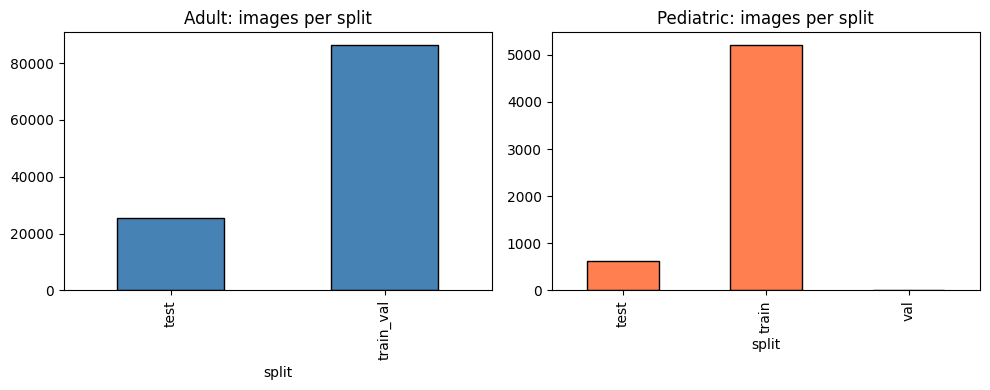

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

def manifest_counts(path, label):
    df = pd.read_csv(path)
    if REMAP:
        df = apply_remap_df(df, REMAP)
    df, n_miss = filter_existing(df)
    print(f"{label}: {len(df)} rows on disk ({n_miss} paths missing)")
    if df.empty:
        return None
    ct = df.groupby(["split", "label"]).size().unstack(fill_value=0)
    ct = ct.rename(columns={0: "normal (0)", 1: "pneumonia (1)"})
    print(ct.to_string(), "\n")
    return ct

adult_ct = manifest_counts(ADULT_CSV, "Adult (NIH)")
ped_ct = manifest_counts(PED_CSV, "Pediatric (Kermany)")

if adult_ct is not None and ped_ct is not None:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    adult_ct.sum(axis=1).plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
    axes[0].set_title("Adult: images per split")
    axes[0].set_xlabel("split")
    ped_ct.sum(axis=1).plot(kind="bar", ax=axes[1], color="coral", edgecolor="black")
    axes[1].set_title("Pediatric: images per split")
    axes[1].set_xlabel("split")
    plt.tight_layout()
    plt.show()

### 2. Visual exploration

Random **thumbnails** per class (after filters) and a **2×2 lay-audience** figure (adult vs pediatric × normal vs pneumonia).

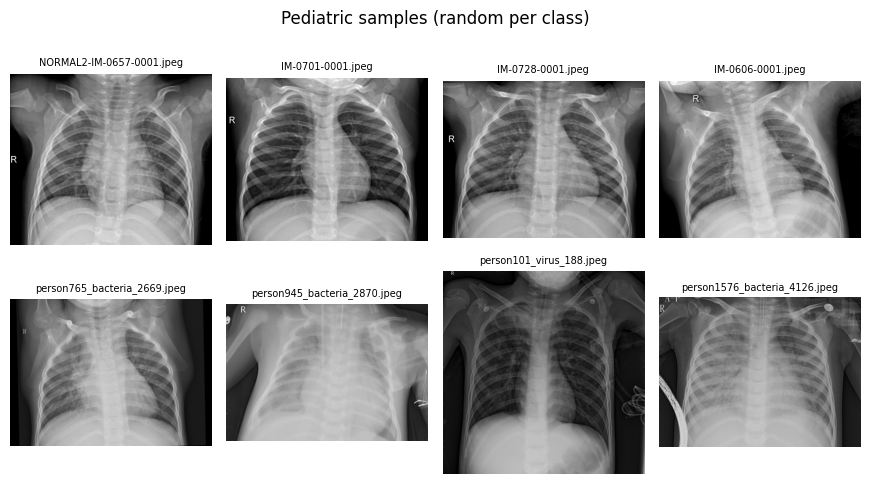

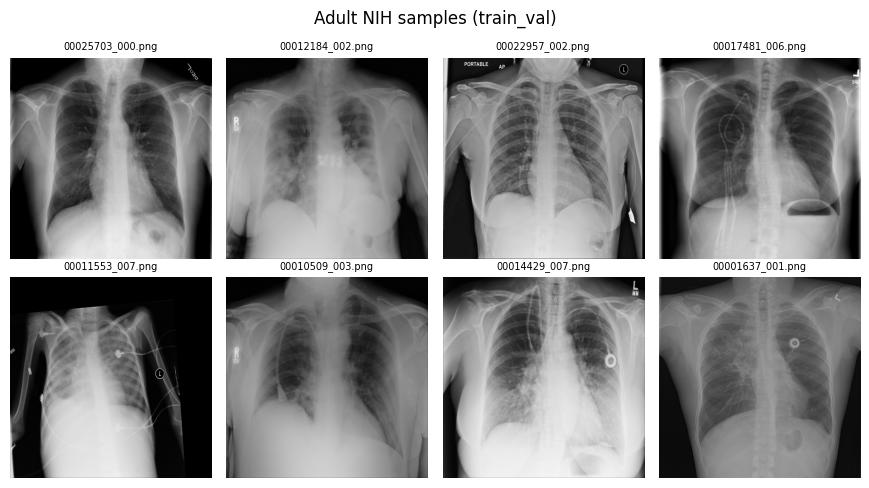

In [4]:
# Optional: sample X-rays → outputs/samples_*.png
from cxr_data import plot_xray_grid

out_dir = PROJECT / "outputs"
out_dir.mkdir(exist_ok=True)

plot_xray_grid(
    PED_CSV, title="Pediatric samples (random per class)", n_per_class=4,
    remap=REMAP, split="train", out_path=out_dir / "samples_pediatric_train.png", seed=42,
)
for adult_split, tag in [("train_val", "train_val"), ("train", "train"), (None, "all_splits")]:
    try:
        plot_xray_grid(
            ADULT_CSV, title=f"Adult NIH samples ({tag})", n_per_class=4,
            remap=REMAP, split=adult_split, out_path=out_dir / f"samples_adult_{tag}.png", seed=42,
        )
        break
    except RuntimeError:
        continue


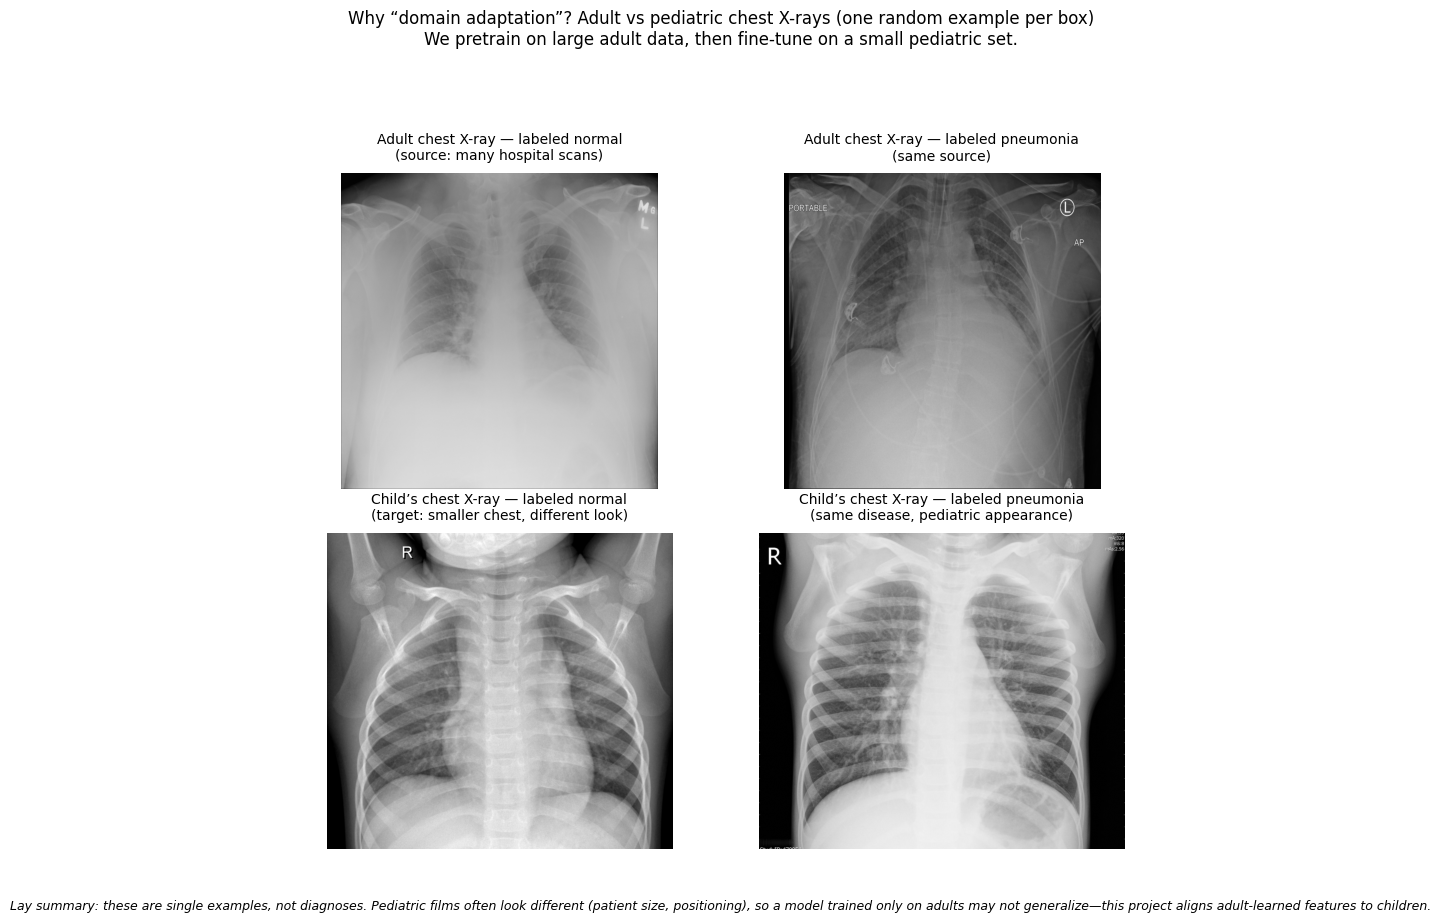

In [5]:
# Figure for non-experts: adult (NIH) vs pediatric (Kermany) side-by-side
from cxr_data import plot_adult_pediatric_layman_figure

out_dir = PROJECT / "outputs"
out_dir.mkdir(exist_ok=True)

plot_adult_pediatric_layman_figure(
    ADULT_CSV,
    PED_CSV,
    remap=REMAP,
    adult_split="train_val",  # use "train" if your NIH manifest has no train_val
    pediatric_split="train",
    out_path=out_dir / "adult_vs_pediatric_layman_2x2.png",
    seed=42,
)


### 3. Training: adult CLIP pretrain → pediatric fine-tune

Default **`text_encoder_train_mode="frozen"`** in `train_adult_clip` keeps BERT + projection fixed so class prompts stay separable; only the image encoder and `logit_scale` update on adult data. Pediatric fine-tuning then aligns images to fixed text embeddings.


In [6]:
import torch
import torch.nn.functional as F
from cxr_engine import (
    collect_image_embeddings, evaluate_clip_classifier, finetune_pediatric_clip,
    load_prompt_tensors, plot_tsne_before_after, prepare_loaders_from_manifests,
    save_proposed_bundle, train_adult_clip,
)
from cxr_model import ImageTextModel

# ========= Hyperparameters =========
IMAGE_SIZE = 224
BATCH_SIZE = 16
IMAGE_BACKBONE = "resnet18"

ADULT_EPOCHS = 5
PED_EPOCHS = 5
LR_ADULT = 1e-4
LR_PED = 1e-4

SEED = 42
MAX_ADULT_SAMPLES = None  # None = full NIH adult manifest; e.g. 5000 for quick tests

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "| MAX_ADULT_SAMPLES:", MAX_ADULT_SAMPLES)

adult_loader, ped_train_loader, ped_val_loader, ped_test_loader = prepare_loaders_from_manifests(
    ADULT_CSV, PED_CSV, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, remap=REMAP,
    max_adult_samples=MAX_ADULT_SAMPLES,
)
ped_train_ds = ped_train_loader.dataset
input_ids, attention_mask = load_prompt_tensors(PROMPT_PT, device)

model = ImageTextModel(image_backbone=IMAGE_BACKBONE, pretrained_image=True).to(device)
train_adult_clip(model, adult_loader, input_ids, attention_mask, device, ADULT_EPOCHS, LR_ADULT)
model.eval()
with torch.no_grad():
    te = model.encode_text_batch(input_ids, attention_mask)
    te = F.normalize(te, dim=1)
    print(
        "Cosine similarity (normal vs pneumonia prompts) after adult phase:",
        float((te[0] * te[1]).sum()),
    )
emb_before, y_tsne = collect_image_embeddings(model, ped_test_loader, device)
text_frozen = finetune_pediatric_clip(
    model, ped_train_loader, input_ids, attention_mask, device, PED_EPOCHS, LR_PED
)
emb_after, _ = collect_image_embeddings(model, ped_test_loader, device)
out_dir = PROJECT / "outputs"
out_dir.mkdir(exist_ok=True)
plot_tsne_before_after(emb_before, emb_after, y_tsne, out_dir / "tsne_before_after.png")
print("Saved", out_dir / "tsne_before_after.png")

save_proposed_bundle(
    out_dir / "proposed_checkpoint.pt",
    model,
    text_frozen,
    image_size=IMAGE_SIZE,
    image_backbone=IMAGE_BACKBONE,
    max_adult_samples=MAX_ADULT_SAMPLES,
    batch_size=BATCH_SIZE,
)
print("Saved checkpoint for standalone eval:", out_dir / "proposed_checkpoint.pt")


/hpc/group/naderilab/eb408/peft_proteomics/peft_proteomics_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda | MAX_ADULT_SAMPLES: None


/hpc/group/naderilab/eb408/peft_proteomics/peft_proteomics_env/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of

Cosine similarity (normal vs pneumonia prompts) after adult phase: 0.9237578511238098


pediatric ft ep5/5: 100%|██████████| 326/326 [02:22<00:00,  2.29it/s]


Saved /hpc/group/naderilab/eb408/ECE685/outputs/tsne_before_after.png
Saved checkpoint for standalone eval: /hpc/group/naderilab/eb408/ECE685/outputs/proposed_checkpoint.pt


### 4. Pediatric test set (AUC / F1)

Zero-shot style scoring: image embeddings vs fixed text class embeddings (after pediatric fine-tune).


In [7]:
m = evaluate_clip_classifier(
    model, ped_test_loader, input_ids, attention_mask, device, frozen_text_emb=text_frozen
)
print("Pediatric test — AUC:", m.auc, " F1:", m.f1)


Pediatric test — AUC: 0.9543063773833006  F1: 0.895040369088812


### 5. Qualitative predictions

Grid of pediatric test patches with ground-truth label and predicted probability of pneumonia.


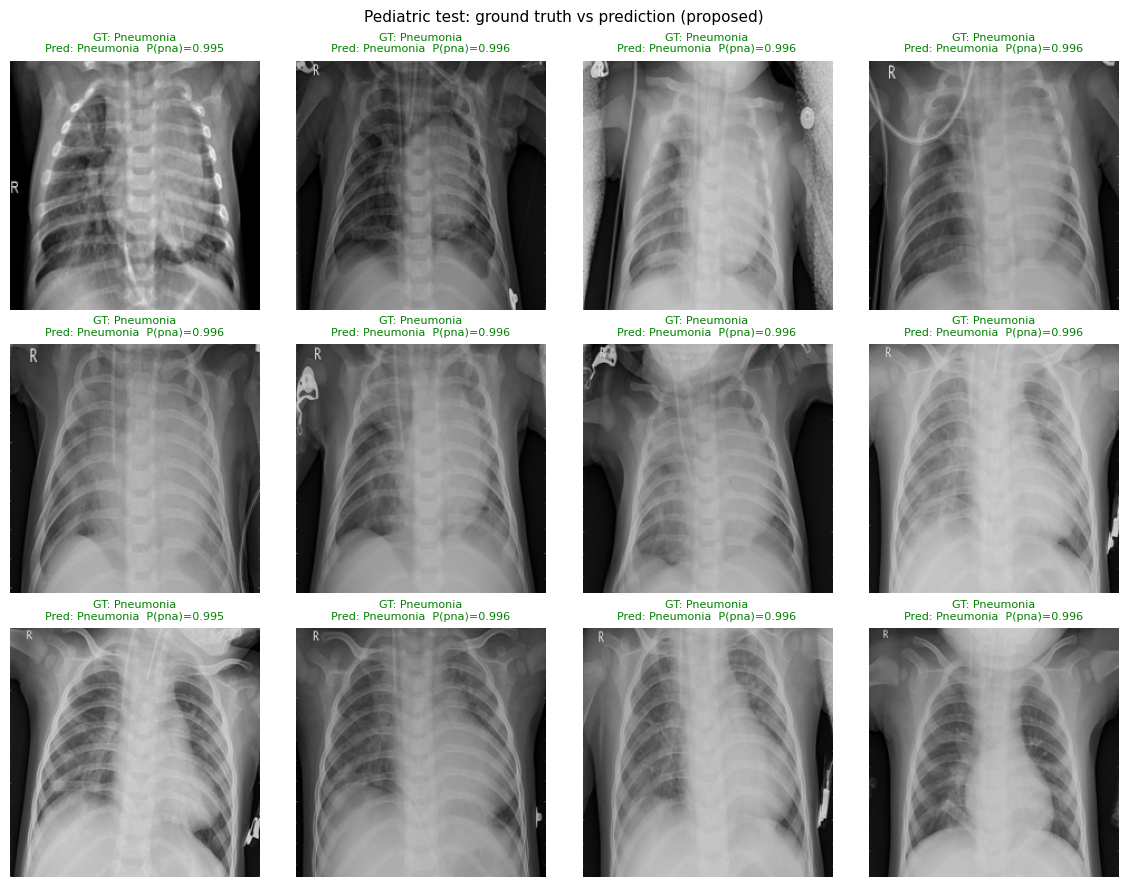

In [8]:
from cxr_engine import plot_prediction_examples

plot_prediction_examples(
    model, ped_test_loader, input_ids, attention_mask, device, frozen_text_emb=text_frozen,
    n_show=12, out_path=out_dir / "prediction_examples_pediatric_test.png",
    title="Pediatric test: ground truth vs prediction (proposed)",
)


### Pipeline overview

```mermaid
flowchart LR
  NIH["NIH ChestX-ray14
  adult images"] --> A["Adult CLIP-style
  image + text prompts"]
  TXT["BERT prompts
  normal / pneumonia"] --> A
  A --> B["Pediatric fine-tune
  Kermany train"]
  K["Kermany pediatric
  images"] --> B
  B --> C["Pediatric val / test
  AUC, F1, plots"]
```

### Limitations, ethics, and data sources

- **Not clinical use:** Course project; outputs are for research education only, not diagnosis.
- **Labels & shift:** NIH and Kermany use different labeling pipelines; pediatric images look different from adult films (domain shift).
- **Class balance:** Pediatric splits may be imbalanced; report AUC, PR, and confusion metrics together.
- **Data:** NIH ChestX-ray14 (adult); Kermany pediatric pneumonia dataset — cite the official papers in your report.


In [9]:
# --- Supervised baseline vs proposed (same pediatric test set) ---
RUN_BASELINE = False  # set True after training proposed model; retrains ResNet+head on pediatric train only
BASELINE_EPOCHS = 5
LR_BASELINE = 1e-4

if RUN_BASELINE:
    import numpy as np
    from cxr_engine import evaluate_baseline, train_baseline
    from cxr_eval_viz import plot_metrics_comparison_bars, plot_roc_comparison

    out_dir = PROJECT / "outputs"
    out_dir.mkdir(exist_ok=True)
    bl = train_baseline(
        ped_train_loader,
        ped_val_loader,
        device,
        BASELINE_EPOCHS,
        LR_BASELINE,
        backbone=IMAGE_BACKBONE,
        pretrained=True,
    )
    ev_bl = evaluate_baseline(bl, ped_test_loader, device)
    print("Baseline (pediatric-only ResNet) — test AUC:", ev_bl.auc, " F1:", ev_bl.f1)

    plot_roc_comparison(
        m.labels,
        m.probs_positive,
        ev_bl.probs_positive,
        "Proposed (CLIP-style)",
        "Baseline (supervised ResNet)",
        out_dir / "roc_proposed_vs_baseline.png",
    )
    plot_metrics_comparison_bars(
        ["Proposed", "Baseline"],
        [float(m.auc), float(ev_bl.auc)],
        [float(m.f1), float(ev_bl.f1)],
        out_dir / "metrics_bars_proposed_vs_baseline.png",
    )
    print("Saved", out_dir / "roc_proposed_vs_baseline.png", out_dir / "metrics_bars_proposed_vs_baseline.png")
else:
    print("Skipping baseline comparison (set RUN_BASELINE = True; requires cells through §4 test metrics `m`).")


Skipping baseline comparison (set RUN_BASELINE = True; requires cells through §4 test metrics `m`).


## Discussion (report)
- When adult pretraining helps vs baseline; when the gap closes as pediatric data grows.
- Alternatives: DANN, MMD/CORAL, SimCLR — see course spec.


## 6. Full evaluation plots (standalone)

**Figures:** ROC, precision–recall, confusion matrix @0.5, score histograms, F1 vs threshold, calibration curve, bootstrap AUC CI (`metrics.txt`), failure-mode thumbnails, Grad-CAM (ResNet only).

**Additional PNGs** (from `run_evaluation_figures`): normalized confusion matrix, sensitivity/specificity/PPV/NPV bar chart, score boxplots by class, Youden's J vs threshold.


In [1]:
# === Standalone evaluation (no cxr_engine.load_proposed_bundle needed) ===
from pathlib import Path
import os
import sys

import pandas as pd
import torch

PROJECT = Path.cwd().resolve()
sys.path.insert(0, str(PROJECT))
os.chdir(PROJECT)

from cxr_data import load_path_remap
from cxr_engine import evaluate_clip_classifier, load_prompt_tensors, prepare_loaders_from_manifests
from cxr_model import ImageTextModel
from cxr_eval_viz import (
    pick_failure_indices,
    plot_failure_mode_grid,
    plot_gradcam_panel,
    run_evaluation_figures,
)

CHECKPOINT = PROJECT / "outputs" / "proposed_checkpoint.pt"
REMAP = load_path_remap()
ADULT_CSV = PROJECT / "data/processed/adult_manifest.csv"
PED_CSV = PROJECT / "data/processed/pediatric_manifest.csv"
PROMPT_PT = PROJECT / "data/processed/bert_prompt_tokens.pt"
EV_OUT = PROJECT / "outputs" / "eval_figures"
EV_OUT.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if not CHECKPOINT.is_file():
    raise FileNotFoundError(
        f"Missing {CHECKPOINT}. Run the training cell (section 3) once; it saves the checkpoint after t-SNE."
    )

# Load checkpoint dict (same format as cxr_engine.save_proposed_bundle — works without importing that helper)
ckpt = torch.load(CHECKPOINT, map_location=device)
backbone = ckpt["image_backbone"]
model = ImageTextModel(image_backbone=backbone, pretrained_image=True).to(device)
model.load_state_dict(ckpt["model_state_dict"])
text_frozen = ckpt["frozen_text_emb"].to(device)
IMAGE_SIZE = int(ckpt["image_size"])
BATCH_SIZE = int(ckpt.get("batch_size", 16))


MAX_ADULT = ckpt.get("max_adult_samples")
if MAX_ADULT is not None and pd.isna(MAX_ADULT):
    MAX_ADULT = None

_, _, _, ped_test_loader = prepare_loaders_from_manifests(
    ADULT_CSV,
    PED_CSV,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    remap=REMAP,
    max_adult_samples=MAX_ADULT,
)
input_ids, attention_mask = load_prompt_tensors(PROMPT_PT, device)

m = evaluate_clip_classifier(
    model, ped_test_loader, input_ids, attention_mask, device, frozen_text_emb=text_frozen
)
labels = m.labels
probs = m.probs_positive

metrics = run_evaluation_figures(
    labels, probs, EV_OUT, prefix="pediatric_test", bootstrap_n=2000, seed=42
)
print("Metrics:", metrics)
print("Figures + metrics.txt ->", EV_OUT)

# Failure-mode samples (FP / FN / TP / TN)
buckets = pick_failure_indices(labels, probs, threshold=0.5)
ped_ds = ped_test_loader.dataset
paths = ped_ds.paths
idxs = []
titles = []
for key, pretty in [("fp", "FP"), ("fn", "FN"), ("tp", "TP"), ("tn", "TN")]:
    for j in buckets[key][:3]:
        idxs.append(j)
        titles.append(pretty)
if idxs:
    plot_failure_mode_grid(paths, labels, probs, idxs, titles, EV_OUT / "failure_mode_samples.png")
    print("Saved", EV_OUT / "failure_mode_samples.png")

# Grad-CAM (ResNet backbones only)
try:
    gc_idx = (buckets["fp"][:2] + buckets["fn"][:2])[:4]
    if not gc_idx:
        gc_idx = [0, 1, min(2, len(labels) - 1), min(3, len(labels) - 1)]
    plot_gradcam_panel(
        model, ped_ds, gc_idx, text_frozen, device, EV_OUT / "gradcam_panel.png"
    )
    print("Saved", EV_OUT / "gradcam_panel.png")
except Exception as ex:
    print("Grad-CAM skipped:", ex)


/hpc/group/naderilab/eb408/peft_proteomics/peft_proteomics_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


/hpc/group/naderilab/eb408/peft_proteomics/peft_proteomics_env/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of

Metrics: {'auc': 0.9543063773833006, 'f1_at_0.5': 0.895040369088812, 'best_f1_threshold': 0.99, 'best_f1': 0.9385194479297365, 'sensitivity': 0.9948717948717949, 'specificity': 0.6196581196581197, 'ppv': 0.8134171907756813, 'npv': 0.9863945578231292, 'auc_bootstrap_lo': 0.9330437873932935, 'auc_bootstrap_hi': 0.9722104980834576}
Figures + metrics.txt -> /hpc/group/naderilab/eb408/ECE685/outputs/eval_figures
Saved /hpc/group/naderilab/eb408/ECE685/outputs/eval_figures/failure_mode_samples.png
Saved /hpc/group/naderilab/eb408/ECE685/outputs/eval_figures/gradcam_panel.png
